# # Загрузка и предварительная обработка данных
# Датасет: Stock Market Dataset (Kaggle)


# ## Загрузка датасета
# Из-за большого объёма берём топ-100 файлов по размеру.


In [28]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [29]:
# путь к папке stocks
STOCKS_PATH = r"C:\Users\nikpa\OneDrive\Документы\Николя Учёба\Магистратура ВШЭ\1 курс\JupyterProject\data\stocks"

all_files = glob.glob(os.path.join(STOCKS_PATH, "*.csv"))
print(f"Найдено файлов: {len(all_files)}")

# сортируем по размеру — большой файл = больше исторических данных
all_files_sorted = sorted(all_files, key=lambda f: os.path.getsize(f), reverse=True)
files_to_use = all_files_sorted[:100]

print("Топ-10 крупнейших файлов:")
for f in files_to_use[:10]:
    size_kb = os.path.getsize(f) // 1024
    print(f"{os.path.basename(f):20} {size_kb} KB")


Найдено файлов: 5884
Топ-10 крупнейших файлов:
HPQ.csv              1628 KB
GE.csv               1606 KB
DIS.csv              1602 KB
ARNC.csv             1569 KB
AA.csv               1568 KB
IP.csv               1545 KB
MO.csv               1450 KB
BA.csv               1438 KB
KO.csv               1412 KB
MRO.csv              1362 KB


In [30]:
# объединяем все файлы в одну таблицу
dataframes = []
for filepath in files_to_use:
    df = pd.read_csv(filepath)
    ticker = os.path.basename(filepath).replace(".csv", "")
    df["ticker"] = ticker
    dataframes.append(df)

df_all = pd.concat(dataframes, ignore_index=True)

print(f"Итого строк: {len(df_all)}")
print(f"Итого компаний: {df_all['ticker'].nunique()}")
print(f"Колонки: {list(df_all.columns)}")
df_all.head()


Итого строк: 1205202
Итого компаний: 100
Колонки: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'ticker']


,Date,Open,High,Low,Close,Adj Close,Volume,ticker
0,1962-01-02,0.131273,0.131273,0.124177,0.124177,0.006887,2480300.0,HPQ
1,1962-01-03,0.124177,0.124177,0.121516,0.122846,0.006813,507300.0,HPQ
2,1962-01-04,0.122846,0.126838,0.117968,0.120185,0.006666,845500.0,HPQ
3,1962-01-05,0.119742,0.119742,0.117525,0.117525,0.006518,338200.0,HPQ
4,1962-01-08,0.117525,0.119299,0.115307,0.119299,0.006617,873700.0,HPQ


# ## Информация по признакам
# * Date — Дата торгов
# * Open — Цена открытия
# * High — Максимальная цена за день
# * Low — Минимальная цена за день
# * Close — Цена закрытия (скорректированная на сплиты)
# * Adj Close — Скорректированная цена закрытия (учитывает сплиты и дивиденды)
# * Volume — Объём торгов
# * ticker — Тикер компании (добавлен при объединении файлов)


# ## Шаг 1: Проверка пропусков


In [31]:
print("Пропуски до удаления:")
print(df_all.isnull().sum())

df_all = df_all.dropna()
print(f"\nСтрок после удаления пропусков: {len(df_all)}")


Пропуски до удаления:
Date          0
Open         24
High         24
Low          24
Close        24
Adj Close    24
Volume       24
ticker        0
dtype: int64

Строк после удаления пропусков: 1205178


# ## Шаг 2: Проверка дубликатов


In [32]:
print(f"Дубликатов: {df_all.duplicated().sum()}")
df_all = df_all.drop_duplicates()
print(f"Строк после удаления дубликатов: {len(df_all)}")


Дубликатов: 0
Строк после удаления дубликатов: 1205178


# ## Шаг 3: Обработка типов данных


In [33]:
# Date — конвертируем из строки в дату
df_all["Date"] = pd.to_datetime(df_all["Date"])
print(f"Тип Date: {df_all['Date'].dtype}")

# Volume — проверяем есть ли дробные значения
has_fractional = (df_all["Volume"] % 1 != 0).sum()
print(f"Строк с дробным Volume: {has_fractional}")

# дробных нет — делаем int
df_all["Volume"] = df_all["Volume"].astype(int)
df_all.info()


Тип Date: datetime64[ns]
Строк с дробным Volume: 0
<class 'pandas.core.frame.DataFrame'>
Index: 1205178 entries, 0 to 1205201
Data columns (total 8 columns):
 #   Column     Non-Null Count    Dtype         
---  ------     --------------    -----         
 0   Date       1205178 non-null  datetime64[ns]
 1   Open       1205178 non-null  float64       
 2   High       1205178 non-null  float64       
 3   Low        1205178 non-null  float64       
 4   Close      1205178 non-null  float64       
 5   Adj Close  1205178 non-null  float64       
 6   Volume     1205178 non-null  int64         
 7   ticker     1205178 non-null  object        
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 82.8+ MB


# ## Шаг 4: Проверка выбросов
# Удаляем только физически невозможные значения.
# Статистические выбросы (IQR) — только смотрим, не удаляем:
# резкий рост Volume это реальное рыночное событие, а не ошибка.


In [34]:
print("-- Шаг 4.1: Отрицательные и нулевые значения --")
price_cols = ["Open", "High", "Low", "Close", "Adj Close"]
for col in price_cols:
    count = (df_all[col] <= 0).sum()
    print(f"  {col} <= 0: {count} строк")

count_vol = (df_all["Volume"] <= 0).sum()
print(f"  Volume <= 0: {count_vol} строк")

for col in price_cols:
    df_all = df_all[df_all[col] > 0]
df_all = df_all[df_all["Volume"] > 0]
print(f"  Строк после очистки: {len(df_all)}\n")

print("-- Шаг 4.2: Логические противоречия --")
invalid_lh = (df_all["Low"] > df_all["High"]).sum()
print(f"  Low > High: {invalid_lh} строк")
df_all = df_all[df_all["Low"] <= df_all["High"]]
print(f"  Строк после очистки: {len(df_all)}\n")

print("-- Шаг 4.3: Open и Close вне диапазона [Low, High] --")
invalid_open = ((df_all["Open"] < df_all["Low"]) |
                (df_all["Open"] > df_all["High"])).sum()
invalid_close = ((df_all["Close"] < df_all["Low"]) |
                 (df_all["Close"] > df_all["High"])).sum()
print(f"  Open вне [Low, High]: {invalid_open} строк")
print(f"  Close вне [Low, High]: {invalid_close} строк")

df_all = df_all[
    (df_all["Open"] >= df_all["Low"]) &
    (df_all["Open"] <= df_all["High"])
]
df_all = df_all[
    (df_all["Close"] >= df_all["Low"]) &
    (df_all["Close"] <= df_all["High"])
]
print(f"  Строк после очистки: {len(df_all)}\n")

print("-- Шаг 4.4: Статистические выбросы (IQR) — только смотрим --")
for col in ["Open", "High", "Low", "Close", "Adj Close", "Volume"]:
    Q1 = df_all[col].quantile(0.25)
    Q3 = df_all[col].quantile(0.75)
    IQR = Q3 - Q1
    count = ((df_all[col] < Q1 - 1.5 * IQR) |
             (df_all[col] > Q3 + 1.5 * IQR)).sum()
    print(f"  Выбросов {col}: {count} ({count / len(df_all) * 100:.1f}%) — не удаляем")

print(f"\nИтого строк после всех проверок: {len(df_all)}")


-- Шаг 4.1: Отрицательные и нулевые значения --
  Open <= 0: 121257 строк
  High <= 0: 0 строк
  Low <= 0: 0 строк
  Close <= 0: 0 строк
  Adj Close <= 0: 0 строк
  Volume <= 0: 20710 строк
  Строк после очистки: 1063256

-- Шаг 4.2: Логические противоречия --
  Low > High: 0 строк
  Строк после очистки: 1063256

-- Шаг 4.3: Open и Close вне диапазона [Low, High] --
  Open вне [Low, High]: 26 строк
  Close вне [Low, High]: 1 строк
  Строк после очистки: 1063229

-- Шаг 4.4: Статистические выбросы (IQR) — только смотрим --
  Выбросов Open: 76388 (7.2%) — не удаляем
  Выбросов High: 76244 (7.2%) — не удаляем
  Выбросов Low: 76514 (7.2%) — не удаляем
  Выбросов Close: 76403 (7.2%) — не удаляем
  Выбросов Adj Close: 84550 (8.0%) — не удаляем
  Выбросов Volume: 98383 (9.3%) — не удаляем

Итого строк после всех проверок: 1063229


# ## Шаг 5: Создание целевого признака target
# Задача — бинарная классификация:
# * 1 -> цена Adj Close завтра ВЫШЕ чем сегодня
# * 0 -> цена Adj Close завтра НИЖЕ или равна сегодняшней


In [35]:
# сортируем по компании и дате — ОБЯЗАТЕЛЬНО перед shift
df_all = df_all.sort_values(["ticker", "Date"]).reset_index(drop=True)

# shift(-1) берёт значение следующей строки (следующий день)
# groupby гарантирует сдвиг внутри одной компании
df_all["target"] = (
    df_all.groupby("ticker")["Adj Close"].shift(-1) > df_all["Adj Close"]
).astype("Int64")

# последняя строка каждой компании получает NaN — удаляем
df_all = df_all.dropna(subset=["target"])
df_all["target"] = df_all["target"].astype(int)

print("Распределение целевого признака:")
print(df_all["target"].value_counts())
print(f"\nПроцентное соотношение:")
print(df_all["target"].value_counts(normalize=True).mul(100).round(2))
print(f"\nВсего строк: {len(df_all)}")


Распределение целевого признака:
target
0    564161
1    499068
Name: count, dtype: int64

Процентное соотношение:
target
0    53.06
1    46.94
Name: proportion, dtype: float64

Всего строк: 1063229


# ## Шаг 6: Feature Engineering
# Создаём новые признаки ДО нормализации — на оригинальных данных.
#
# Почему ДО нормализации:
# MA от уже нормализованных данных коррелирует 1.00 с Adj Close
# и не несёт новой информации для модели.
#
# Что добавляем и зачем:
# * volatility     — нервозность рынка внутри дня
# * MA5_ratio      — отклонение цены от 5-дневного тренда
# * MA20_ratio     — отклонение цены от 20-дневного тренда
# * MA_cross       — пересечение краткосрочного и долгосрочного трендов
# * price_change   — импульс за 1 день
# * return_5d      — импульс за 5 дней (неделя)
# * return_20d     — импульс за 20 дней (месяц)
# * volume_ratio   — объём относительно нормы (повышенный интерес?)
# * std_20d        — волатильность за 20 дней (нервозность периода)
# * day_of_week    — день недели (рынок ведёт себя по-разному)
# * month          — месяц (сезонные паттерны)


In [36]:
# ВАЖНО: берём только данные с 2000 года
# рынок 1962 года сильно отличается от современного
# старые данные добавляют шум, а не полезные паттерны
df_all = df_all[df_all["Date"] >= "2000-01-01"].copy()
df_all = df_all.sort_values(["ticker", "Date"]).reset_index(drop=True)
print(f"Строк после фильтрации (с 2000 года): {len(df_all)}")


Строк после фильтрации (с 2000 года): 506689


In [37]:
# volatility — создаём ПЕРВЫМ пока High и Low ещё существуют
# процентная волатильность: на сколько % колебалась цена за день
# используем процент а не абсолютную разницу
# иначе дорогие акции (Google 2000$) будут иметь искусственно высокую volatility
df_all["volatility"] = (df_all["High"] - df_all["Low"]) / df_all["Low"]

# считаем сырые скользящие средние — нужны для ratio и cross
ma5_raw = df_all.groupby("ticker")["Adj Close"].transform(
    lambda x: x.rolling(window=5).mean()
)
ma20_raw = df_all.groupby("ticker")["Adj Close"].transform(
    lambda x: x.rolling(window=20).mean()
)

# MA5_ratio: > 1.0 = цена выше краткосрочного тренда (бычий сигнал)
df_all["MA5_ratio"] = df_all["Adj Close"] / ma5_raw

# MA20_ratio: > 1.0 = цена выше долгосрочного тренда (бычий сигнал)
df_all["MA20_ratio"] = df_all["Adj Close"] / ma20_raw

# MA_cross: > 0 = краткосрочный тренд сильнее долгосрочного
df_all["MA_cross"] = ma5_raw - ma20_raw

# price_change: изменение цены за 1 день
df_all["price_change"] = df_all.groupby("ticker")["Adj Close"].transform(
    lambda x: x.pct_change()
)

# return_5d: изменение цены за 5 дней (моментум недели)
# показывает силу тренда за последние 5 торговых дней
df_all["return_5d"] = df_all.groupby("ticker")["Adj Close"].transform(
    lambda x: x.pct_change(periods=5)
)

# return_20d: изменение цены за 20 дней (моментум месяца)
df_all["return_20d"] = df_all.groupby("ticker")["Adj Close"].transform(
    lambda x: x.pct_change(periods=20)
)

# volume_ratio: объём сегодня относительно среднего за 20 дней
# > 1.0 = сегодня торгуют активнее чем обычно (повышенный интерес)
vol_ma20 = df_all.groupby("ticker")["Volume"].transform(
    lambda x: x.rolling(window=20).mean()
)
df_all["volume_ratio"] = df_all["Volume"] / vol_ma20

# std_20d: стандартное отклонение цены за 20 дней
# высокое std = рынок нервничает = меньше предсказуемости
df_all["std_20d"] = df_all.groupby("ticker")["Adj Close"].transform(
    lambda x: x.rolling(window=20).std()
)

# день недели: 0=понедельник, 4=пятница
df_all["day_of_week"] = df_all["Date"].dt.dayofweek

# месяц: 1=январь, 12=декабрь
df_all["month"] = df_all["Date"].dt.month

# удаляем ненужные колонки
# Open, High, Low — дублируют Adj Close (корреляция 0.99-1.00)
# Close — заменён на Adj Close (более честная цена без дивидендных артефактов)
df_all = df_all.drop(columns=["Open", "High", "Low", "Close"])

# удаляем NaN — появляются из-за rolling(window=20) и pct_change(periods=20)
df_all = df_all.dropna()

print(f"Строк после Feature Engineering: {len(df_all)}")
print(f"Колонки: {list(df_all.columns)}")


Строк после Feature Engineering: 504689
Колонки: ['Date', 'Adj Close', 'Volume', 'ticker', 'target', 'volatility', 'MA5_ratio', 'MA20_ratio', 'MA_cross', 'price_change', 'return_5d', 'return_20d', 'volume_ratio', 'std_20d', 'day_of_week', 'month']


# ## Шаг 7: EDA — анализ данных
# Проводим EDA ДО нормализации — графики показывают реальные значения.


# ### График 1: Распределение целевого признака


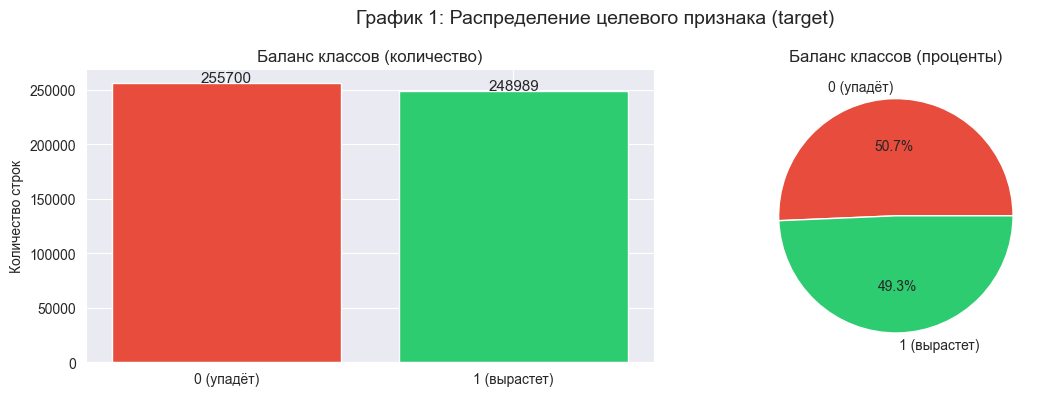

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

target_counts = df_all["target"].value_counts()
target_labels = ["0 (упадёт)", "1 (вырастет)"]

axes[0].bar(target_labels, target_counts.values, color=["#e74c3c", "#2ecc71"])
axes[0].set_title("Баланс классов (количество)")
axes[0].set_ylabel("Количество строк")
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 1000, str(v), ha="center", fontsize=11)

target_pct = df_all["target"].value_counts(normalize=True) * 100
axes[1].pie(target_pct.values, labels=target_labels,
            autopct="%1.1f%%", colors=["#e74c3c", "#2ecc71"])
axes[1].set_title("Баланс классов (проценты)")

plt.suptitle("График 1: Распределение целевого признака (target)", fontsize=14)
plt.tight_layout()
plt.show()


# ### График 2: Распределение Adj Close и Volume


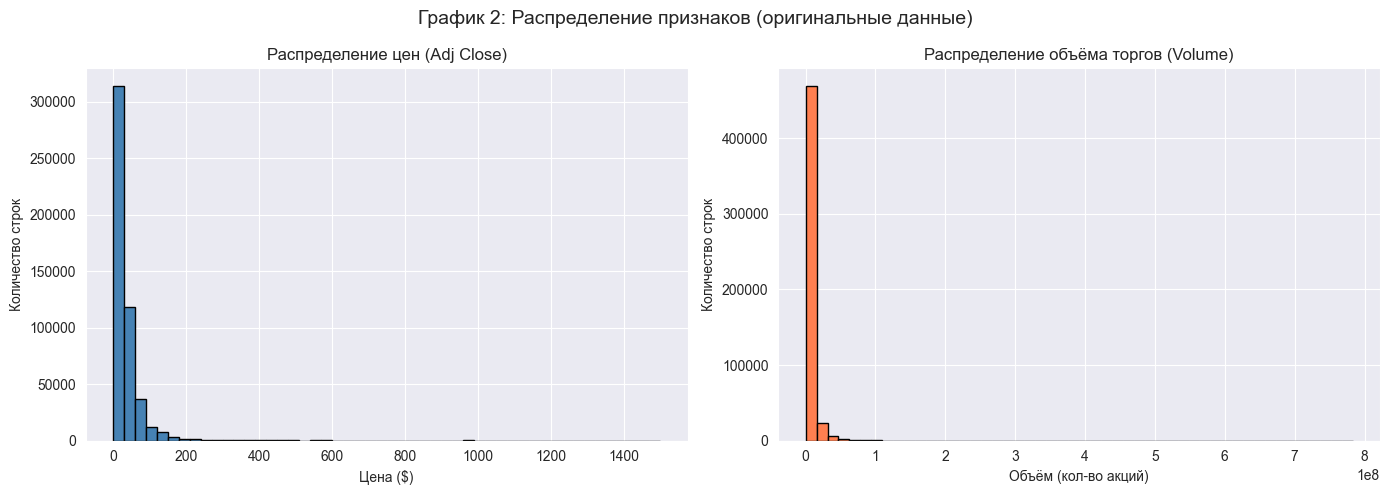

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_all["Adj Close"], bins=50, color="steelblue", edgecolor="black")
axes[0].set_title("Распределение цен (Adj Close)")
axes[0].set_xlabel("Цена ($)")
axes[0].set_ylabel("Количество строк")

axes[1].hist(df_all["Volume"], bins=50, color="coral", edgecolor="black")
axes[1].set_title("Распределение объёма торгов (Volume)")
axes[1].set_xlabel("Объём (кол-во акций)")
axes[1].set_ylabel("Количество строк")

plt.suptitle("График 2: Распределение признаков (оригинальные данные)", fontsize=14)
plt.tight_layout()
plt.show()


# ### График 3: Количество записей по годам


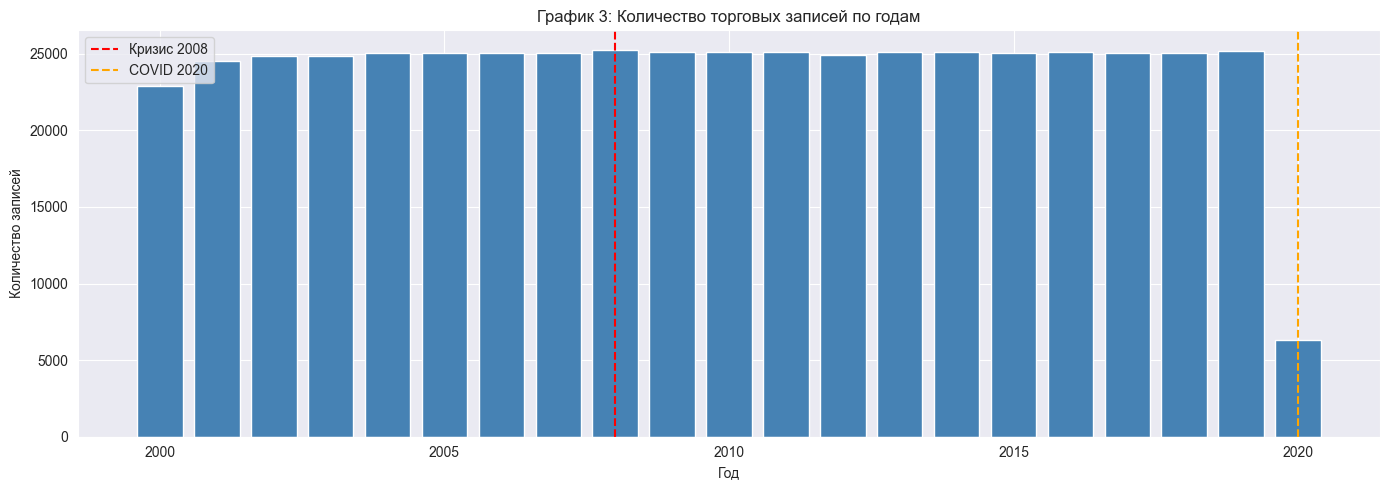

In [40]:
df_all["year"] = df_all["Date"].dt.year
records_per_year = df_all.groupby("year").size()

plt.figure(figsize=(14, 5))
plt.bar(records_per_year.index, records_per_year.values, color="steelblue")
plt.title("График 3: Количество торговых записей по годам")
plt.xlabel("Год")
plt.ylabel("Количество записей")
plt.axvline(x=2008, color="red", linestyle="--", label="Кризис 2008")
plt.axvline(x=2020, color="orange", linestyle="--", label="COVID 2020")
plt.legend()
plt.tight_layout()
plt.show()

df_all = df_all.drop(columns=["year"])


# ### График 4: Корреляционная матрица
# Проверяем что новые признаки не дублируют друг друга.


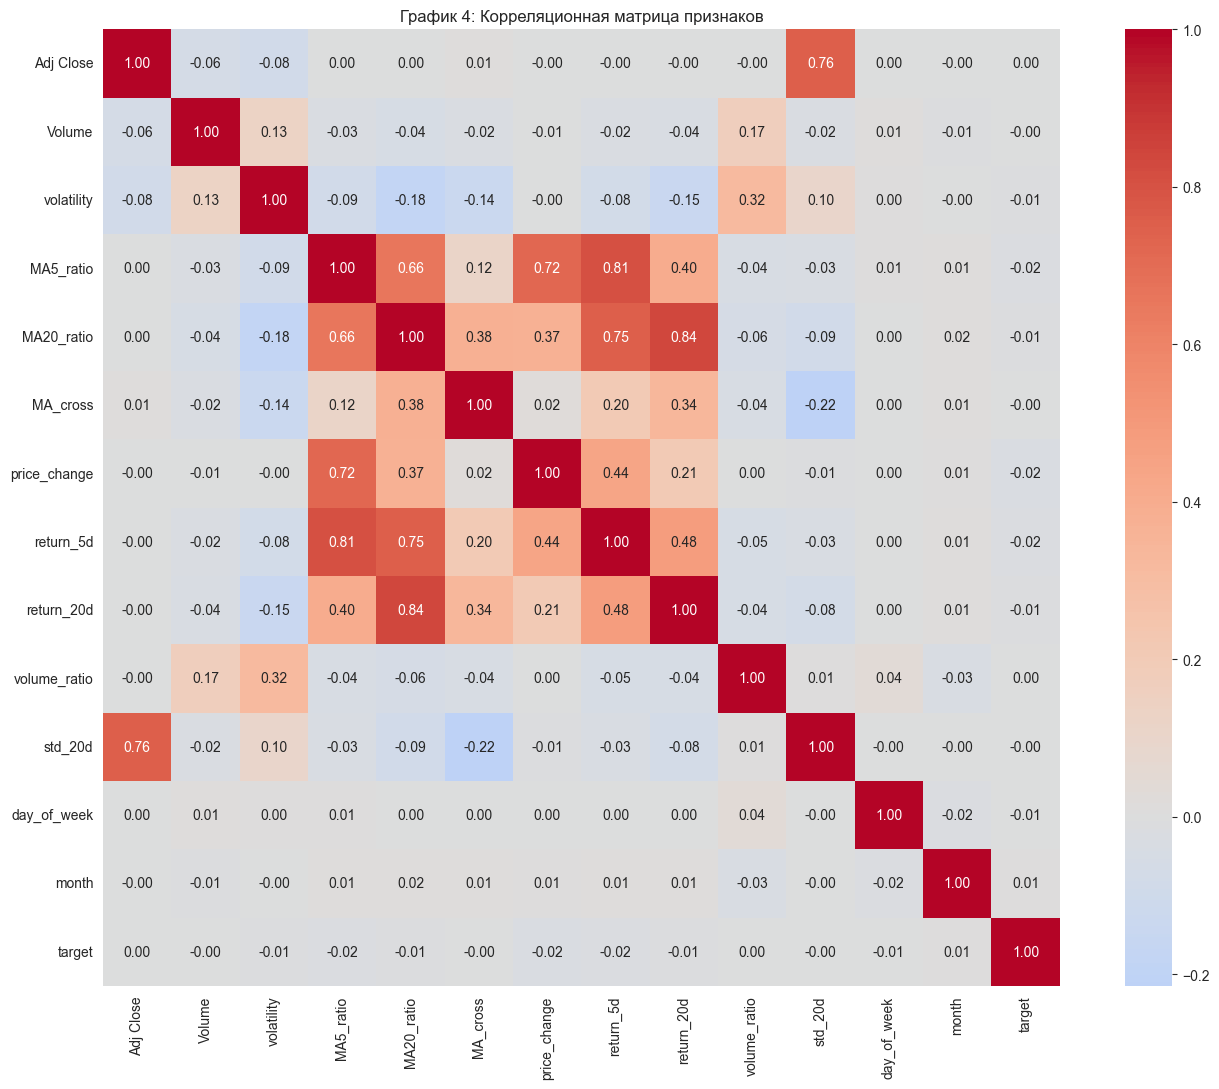

Корреляция каждого признака с target (по убыванию):
price_change   -0.024312
MA5_ratio      -0.019799
return_5d      -0.017047
MA20_ratio     -0.014882
volatility     -0.009883
return_20d     -0.008571
month           0.006758
day_of_week    -0.006074
MA_cross       -0.004696
std_20d        -0.003374
volume_ratio    0.001748
Volume         -0.001593
Adj Close       0.000632
Name: target, dtype: float64


In [41]:
numeric_cols = ["Adj Close", "Volume", "volatility", "MA5_ratio", "MA20_ratio",
                "MA_cross", "price_change", "return_5d", "return_20d",
                "volume_ratio", "std_20d", "day_of_week", "month", "target"]

correlation_matrix = df_all[numeric_cols].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, square=True)
plt.title("График 4: Корреляционная матрица признаков")
plt.tight_layout()
plt.show()

print("Корреляция каждого признака с target (по убыванию):")
print(correlation_matrix["target"].drop("target").sort_values(
    key=abs, ascending=False
))


# ### График 5: Временной ряд одной компании


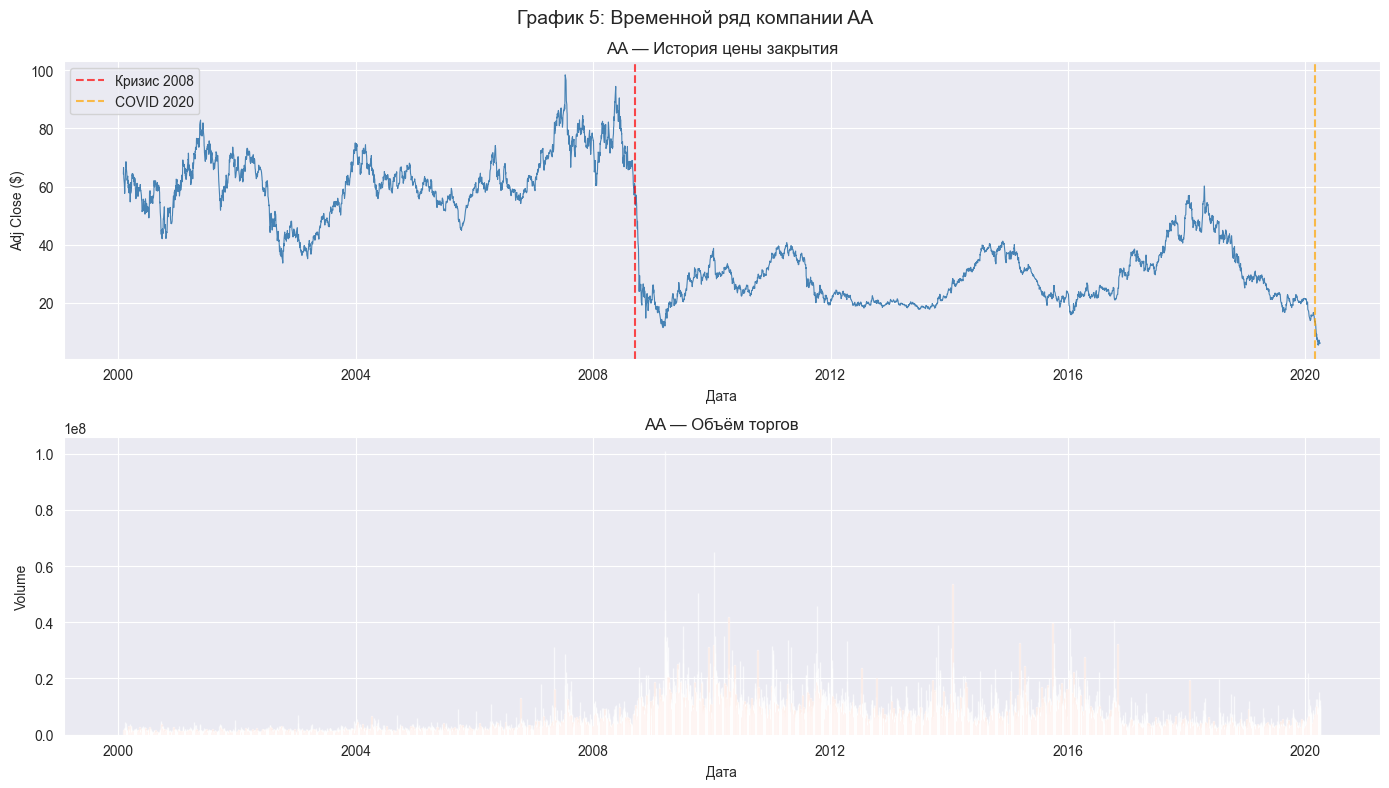

In [42]:
top_ticker = df_all["ticker"].value_counts().index[0]
company_data = df_all[df_all["ticker"] == top_ticker].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(company_data["Date"], company_data["Adj Close"],
             color="steelblue", linewidth=0.8)
axes[0].set_title(f"{top_ticker} — История цены закрытия")
axes[0].set_xlabel("Дата")
axes[0].set_ylabel("Adj Close ($)")
axes[0].axvline(pd.Timestamp("2008-09-15"), color="red",
                linestyle="--", alpha=0.7, label="Кризис 2008")
axes[0].axvline(pd.Timestamp("2020-03-01"), color="orange",
                linestyle="--", alpha=0.7, label="COVID 2020")
axes[0].legend()

axes[1].bar(company_data["Date"], company_data["Volume"],
            color="coral", alpha=0.7, width=1)
axes[1].set_title(f"{top_ticker} — Объём торгов")
axes[1].set_xlabel("Дата")
axes[1].set_ylabel("Volume")

plt.suptitle(f"График 5: Временной ряд компании {top_ticker}", fontsize=14)
plt.tight_layout()
plt.show()


# ## Шаг 8: Нормализация
# Нормализуем ПОСЛЕ EDA — чтобы графики показывали реальные значения.
# Random Forest не требует нормализации, но она нужна для:
# 1. Logistic Regression (сравниваем несколько моделей)
# 2. Consumer в Kafka — должен нормализовать новые данные теми же параметрами


In [51]:
# 1. Сначала разбиваем данные
df_sorted = df_all.sort_values("Date")
split_idx = int(len(df_sorted) * 0.8)

train = df_sorted.iloc[:split_idx].copy()
test  = df_sorted.iloc[split_idx:].copy()

# 2. Обучаем скейлер ТОЛЬКО на train
scaler = MinMaxScaler()
#  все числовые признаки кроме целевого и временных
features_to_scale = ["Adj Close", "Volume", "volatility", "MA5_ratio",
                     "MA20_ratio", "MA_cross", "price_change",
                     "return_5d", "return_20d", "volume_ratio", "std_20d"]
train[features_to_scale] = scaler.fit_transform(train[features_to_scale])

# 3. Применяем (transform) к test
test[features_to_scale] = scaler.transform(test[features_to_scale])

# Сохраняем скейлер
joblib.dump(scaler, "models/scaler.pkl")

['models/scaler.pkl']

In [17]:
from sklearn.preprocessing import MinMaxScaler
import joblib

# нормализуем все числовые признаки кроме целевого и временных
features_to_scale = ["Adj Close", "Volume", "volatility", "MA5_ratio",
                     "MA20_ratio", "MA_cross", "price_change",
                     "return_5d", "return_20d", "volume_ratio", "std_20d"]

scaler = MinMaxScaler()
df_all[features_to_scale] = scaler.fit_transform(df_all[features_to_scale])

print("Минимальные значения после нормализации:")
print(df_all[features_to_scale].min())
print("\nМаксимальные значения после нормализации:")
print(df_all[features_to_scale].max())

# сохраняем скалер — Consumer будет использовать те же параметры нормализации
joblib.dump(scaler, "models/scaler.pkl")
print(f"\nСкалер сохранён. Размер: {os.path.getsize('models/scaler.pkl')} байт")


Минимальные значения после нормализации:
Adj Close       0.0
Volume          0.0
volatility      0.0
MA5_ratio       0.0
MA20_ratio      0.0
MA_cross        0.0
price_change    0.0
return_5d       0.0
return_20d      0.0
volume_ratio    0.0
std_20d         0.0
dtype: float64

Максимальные значения после нормализации:
Adj Close       1.0
Volume          1.0
volatility      1.0
MA5_ratio       1.0
MA20_ratio      1.0
MA_cross        1.0
price_change    1.0
return_5d       1.0
return_20d      1.0
volume_ratio    1.0
std_20d         1.0
dtype: float64

Скалер сохранён. Размер: 1503 байт


# ## Шаг 9: Сохранение датасета


In [52]:
df_all.to_csv("data/dataset_combined.csv", index=False)
print(f"Датасет сохранён: {len(df_all)} строк, {len(df_all.columns)} колонок")
print(f"Колонки: {list(df_all.columns)}")


Датасет сохранён: 504689 строк, 16 колонок
Колонки: ['Date', 'Adj Close', 'Volume', 'ticker', 'target', 'volatility', 'MA5_ratio', 'MA20_ratio', 'MA_cross', 'price_change', 'return_5d', 'return_20d', 'volume_ratio', 'std_20d', 'day_of_week', 'month']


# ## Шаг 10: Обучение и сравнение моделей
#
# Сравниваем три модели:
# 1. Random Forest — ансамбль деревьев, не чувствителен к масштабу
# 2. Gradient Boosting — деревья строятся последовательно, каждое исправляет ошибки предыдущего
# 3. Logistic Regression — простая линейная модель, хороший baseline
#
# Разбивка по времени (а не случайная):
# нельзя обучать на данных 2015 года и проверять на 2010 — модель будет "знать будущее"


In [53]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import joblib

# список признаков для модели
features = ["Adj Close", "Volume", "volatility", "MA5_ratio", "MA20_ratio",
            "MA_cross", "price_change", "return_5d", "return_20d",
            "volume_ratio", "std_20d", "day_of_week", "month"]

# разбивка 80/20 по времени
df_sorted = df_all.sort_values("Date")
split_idx = int(len(df_sorted) * 0.8)

train = df_sorted.iloc[:split_idx]
test  = df_sorted.iloc[split_idx:]

print(f"Train: {len(train)} строк ({train['Date'].min().date()} — {train['Date'].max().date()})")
print(f"Test:  {len(test)} строк  ({test['Date'].min().date()} — {test['Date'].max().date()})")

X_train = train[features]
y_train = train["target"]
X_test  = test[features]
y_test  = test["target"]

print(f"\nX_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"\nNaN в X_train: {X_train.isnull().sum().sum()}")
print(f"NaN в X_test:  {X_test.isnull().sum().sum()}")


Train: 403751 строк (2000-02-01 — 2016-03-28)
Test:  100938 строк  (2016-03-28 — 2020-04-01)

X_train: (403751, 13)
X_test:  (100938, 13)

NaN в X_train: 0
NaN в X_test:  0


In [54]:
# модель 1: Random Forest
# max_depth=8 — ограничиваем глубину чтобы избежать переобучения
# min_samples_leaf=50 — в каждом листе минимум 50 примеров
print("Обучаем Random Forest...")
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_leaf=50,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
acc_rf = accuracy_score(y_test, rf.predict(X_test))
print(f"Random Forest: {acc_rf * 100:.2f}%")


Обучаем Random Forest...
Random Forest: 52.30%


In [55]:
# модель 2: Gradient Boosting
# строит деревья последовательно — каждое исправляет ошибки предыдущего
# обычно точнее чем Random Forest на табличных данных
# learning_rate=0.1 — шаг обучения (меньше = медленнее но точнее)
print("Обучаем Gradient Boosting...")
gb = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.2,
    random_state=42
)
gb.fit(X_train, y_train)
acc_gb = accuracy_score(y_test, gb.predict(X_test))
print(f"Gradient Boosting: {acc_gb * 100:.2f}%")


Обучаем Gradient Boosting...
Gradient Boosting: 51.31%


In [56]:
# модель 3: Logistic Regression
# простая линейная модель — хороший baseline для сравнения
# требует нормализованных данных (у нас уже нормализовано)
print("Обучаем Logistic Regression...")
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
acc_lr = accuracy_score(y_test, lr.predict(X_test))
print(f"Logistic Regression: {acc_lr * 100:.2f}%")


Обучаем Logistic Regression...
Logistic Regression: 51.85%


In [23]:
# сравниваем результаты
print("\n=== Сравнение моделей ===")
results = {
    "Random Forest":      acc_rf,
    "Gradient Boosting":  acc_gb,
    "Logistic Regression": acc_lr
}
for name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"  {name:25} {acc * 100:.2f}%")

# выбираем лучшую модель
best_name = max(results, key=results.get)
best_acc  = results[best_name]
print(f"\nЛучшая модель: {best_name} ({best_acc * 100:.2f}%)")

# сохраняем лучшую модель
model_map = {
    "Random Forest": rf,
    "Gradient Boosting": gb,
    "Logistic Regression": lr
}
best_model = model_map[best_name]
joblib.dump(best_model, "models/model.pkl")
print("Лучшая модель сохранена в models/model.pkl")



=== Сравнение моделей ===
  Random Forest             52.23%
  Gradient Boosting         51.58%
  Logistic Regression       51.13%

Лучшая модель: Random Forest (52.23%)
Лучшая модель сохранена в models/model.pkl


In [57]:
# подробный отчёт по лучшей модели
y_pred = best_model.predict(X_test)
print(f"\nПодробный отчёт ({best_name}):")
print(classification_report(y_test, y_pred,
      target_names=["0 (упадёт)", "1 (вырастет)"]))



Подробный отчёт (Random Forest):
              precision    recall  f1-score   support

  0 (упадёт)       0.48      1.00      0.65     48597
1 (вырастет)       0.65      0.00      0.00     52341

    accuracy                           0.48    100938
   macro avg       0.56      0.50      0.33    100938
weighted avg       0.57      0.48      0.31    100938



# ### График 6: Важность признаков


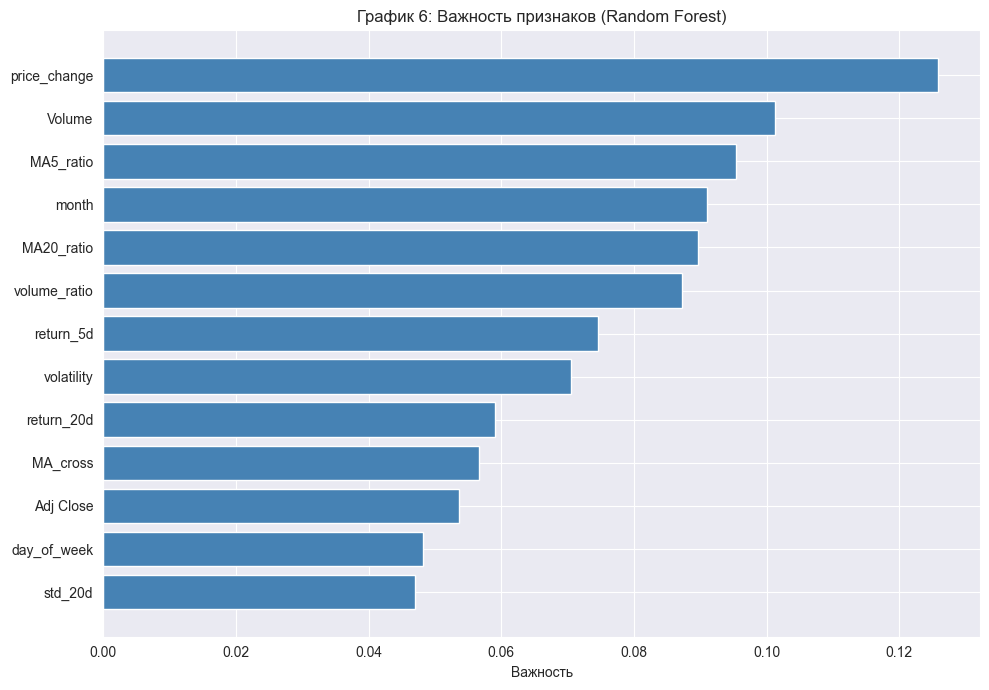

Топ-5 самых важных признаков:
         признак  важность
6   price_change  0.125850
1         Volume  0.101232
3      MA5_ratio  0.095434
12         month  0.090946
4     MA20_ratio  0.089654


In [25]:
# важность признаков доступна только у деревьев
# для Logistic Regression используем коэффициенты
if best_name in ["Random Forest", "Gradient Boosting"]:
    importance = best_model.feature_importances_
else:
    importance = abs(best_model.coef_[0])

feature_importance = pd.DataFrame({
    "признак": features,
    "важность": importance
}).sort_values("важность", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(feature_importance["признак"],
         feature_importance["важность"],
         color="steelblue")
plt.title(f"График 6: Важность признаков ({best_name})")
plt.xlabel("Важность")
plt.tight_layout()
plt.show()

print("Топ-5 самых важных признаков:")
print(feature_importance.sort_values("важность", ascending=False).head())


# ### График 7: Сравнение точности моделей


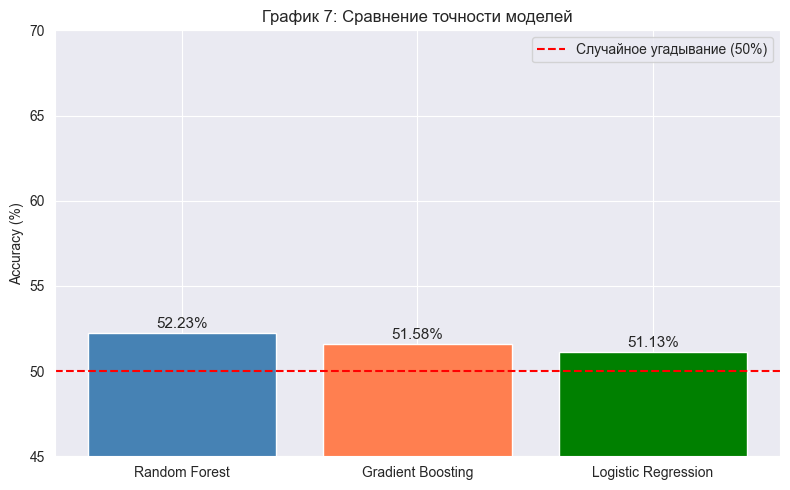

In [26]:
model_names = list(results.keys())
model_accs  = [v * 100 for v in results.values()]

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, model_accs, color=["steelblue", "coral", "green"])
plt.title("График 7: Сравнение точности моделей")
plt.ylabel("Accuracy (%)")
plt.ylim(45, 70)

# линия случайного угадывания (50%)
plt.axhline(y=50, color="red", linestyle="--", label="Случайное угадывание (50%)")
plt.legend()

# подписываем значения на столбцах
for bar, acc in zip(bars, model_accs):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.3,
             f"{acc:.2f}%", ha="center", fontsize=11)

plt.tight_layout()
plt.show()